In [ ]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

(x_train , y_train) ,(x_test , y_test) =mnist.load_data()

8


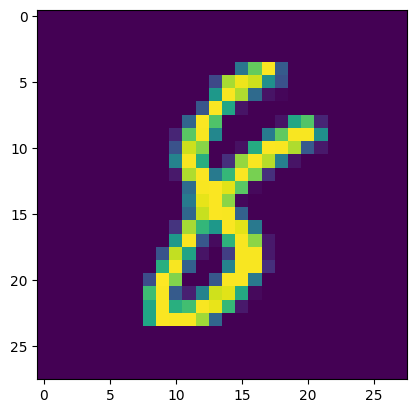

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_test[9900])
print(y_test[9900])

In [ ]:
x_train = x_train/255.0
x_test = x_test/255.0

Build the DNN

In [ ]:
model = tf.keras.models.Sequential()                   # to build our network as FeedForward model
model.add(tf.keras.layers.Flatten())                  # to add flatten layer in first layer which is (Input layer)
model.add(tf.keras.layers.Dense(128,activation=tf.nn.relu)) # Create first Hidden Layer with 128 neurons with Relu Function
model.add(tf.keras.layers.Dense(128,activation=tf.nn.relu))   # Create second Hidden Layer with 128 neurons with Relu Function
model.add(tf.keras.layers.Dense(10,activation='softmax')) # creating output layer with 10 neurons for range 10 to classify and with (Softmax) for (probability Distribution)
model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy' , metrics=['accuracy'])  #to add your parameters
history=model.fit(x_train,y_train , epochs=15,
        validation_data=(x_test, y_test))  # to start train your Network

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.8802 - loss: 0.4036 - val_accuracy: 0.9635 - val_loss: 0.1192
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9708 - loss: 0.0988 - val_accuracy: 0.9698 - val_loss: 0.0929
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9793 - loss: 0.0666 - val_accuracy: 0.9741 - val_loss: 0.0815
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9841 - loss: 0.0493 - val_accuracy: 0.9704 - val_loss: 0.0970
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0402 - val_accuracy: 0.9769 - val_loss: 0.0732
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9910 - loss: 0.0290 - val_accuracy: 0.9767 - val_loss: 0.0825
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9729 - val_loss: 0.0978
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9931 - loss: 0.0212 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.1101
0.09704068303108215 0.9790999889373779
Validation Accuracy: 97.91%


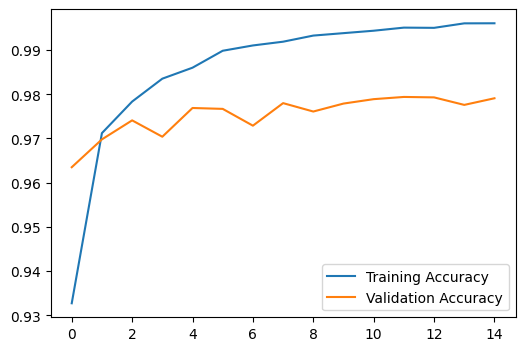

In [ ]:
val_loss , val_acc = model.evaluate(x_test , y_test)
print(val_loss, val_acc)
plt.figure(figsize=(6,4))
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
model.save('epic_num_reader.keras')
new_model=tf.keras.models.load_model('epic_num_reader.keras' , custom_objects={'softmax': tf.nn.softmax})

In [ ]:
predictions = new_model.predict(x_test)
print(predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1.87736891e-15 3.95723417e-15 7.30898970e-15 ... 9.99999940e-01
  2.23099606e-15 4.80459894e-09]
 [2.43711894e-28 1.18261408e-17 9.99999940e-01 ... 7.06895638e-27
  1.60745391e-22 1.74239149e-32]
 [1.08030636e-13 9.99999821e-01 3.53354263e-10 ... 2.63360285e-08
  6.59561472e-09 1.92446341e-12]
 ...
 [2.24869312e-21 1.21291995e-16 2.42156026e-20 ... 8.44693586e-12
  3.62278567e-14 4.15608881e-10]
 [2.11959953e-17 1.11518196e-20 5.29517873e-24 ... 6.84661688e-24
  1.06166389e-07 1.40680028e-19]
 [2.48351280e-18 3.64028720e-19 2.30003773e-19 ... 2.17465360e-25
  1.47804496e-15 4.48042960e-20]]


In [ ]:
import numpy as np
print(np.argmax(predictions[9900]))

8


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


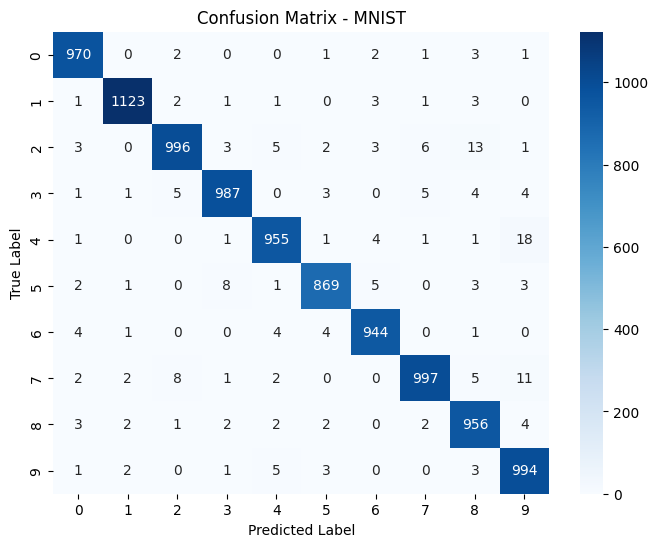

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict test data
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST')
plt.show()
